In [1]:

# PART B - IMPORTS

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms, models

In [2]:

# DATASET CLASS


class Food101Dataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.root = root
        self.transform = transform

        split_file = os.path.join(root, "meta", f"{split}.txt")

        with open(split_file, "r") as f:
            self.image_paths = [line.strip() for line in f.readlines()]

        self.classes = sorted(list(set([p.split("/")[0] for p in self.image_paths])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = path.split("/")[0]

        img_path = os.path.join(self.root, "images", path + ".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.class_to_idx[label]

In [3]:
# TRANSFORMS AND DATASET LOADING


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_root = "./data/food-101/food-101"

train_dataset = Food101Dataset(data_root, split="train", transform=transform)
test_dataset = Food101Dataset(data_root, split="test", transform=transform)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))

Train size: 75750
Test size: 25250
Number of classes: 101


In [4]:

# TRAIN / VALIDATION SPLIT THEN REDUCED SUBSET AND DATALOADERS

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

val_ratio = 0.1
train_size = int((1 - val_ratio) * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_subset_small = Subset(train_subset, range(10000))
val_subset_small = Subset(val_subset, range(2000))

batch_size = 32

train_loader = DataLoader(
    train_subset_small,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset_small,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print("Train subset size:", len(train_subset_small))
print("Validation subset size:", len(val_subset_small))
print("Test size:", len(test_dataset))
print("Batch size:", batch_size)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Using device: cuda
Train subset size: 10000
Validation subset size: 2000
Test size: 25250
Batch size: 32
Train batches: 313
Validation batches: 63
Test batches: 790


In [5]:
# HELPER FUNCTIONS

criterion = nn.CrossEntropyLoss()

def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=2):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print("-" * 50)

    total_time = time.time() - start_time
    return history, total_time

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Helper functions ready.")

Helper functions ready.


In [6]:
# CUSTOM CLASSIFIER


class CustomClassifier(nn.Module):
    def __init__(self, in_features, num_classes=101):
        super(CustomClassifier, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc(x)

print("Custom classifier ready.")

Custom classifier ready.


# Part B - Fine Tuning

MobileNet V3 was selected for fine-tuning because it achieved the highest test accuracy in Part A. In this part, two fine-tuning experiments are performed by progressively unfreezing deeper layers of the pretrained backbone.

In [7]:
# PART B1: LOAD MOBILENET V3 BASE MODEL


mobilenet_ft = models.mobilenet_v3_small(pretrained=True)

for param in mobilenet_ft.parameters():
    param.requires_grad = False

in_features = mobilenet_ft.classifier[3].in_features
mobilenet_ft.classifier[3] = CustomClassifier(in_features)

mobilenet_ft = mobilenet_ft.to(device)

print("MobileNet V3 fine-tuning base model ready.")

c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\mites\Downloads\DeepLearning_A2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MobileNet V3 fine-tuning base model ready.


In [8]:
# PART B2: INSPECT FEATURE BLOCKS

print(mobilenet_ft.features)

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    (2): Hardswish()
  )
  (1): InvertedResidual(
    (block): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): SqueezeExcitation(
        (avgpool): AdaptiveAvgPool2d(output_size=1)
        (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
        (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
        (activation): ReLU()
        (scale_activation): Hardsigmoid()
      )
      (2): Conv2dNormActivation(
        (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, mo

In [9]:
# EXPERIMENT 1: UNFREEZE LAST BLOCK 


mobilenet_ft1 = models.mobilenet_v3_small(pretrained=True)

# Freeze everything
for param in mobilenet_ft1.parameters():
    param.requires_grad = False

# Replace classifier
in_features = mobilenet_ft1.classifier[3].in_features
mobilenet_ft1.classifier[3] = CustomClassifier(in_features)

# Unfreeze classifier
for param in mobilenet_ft1.classifier[3].parameters():
    param.requires_grad = True

# Unfreeze LAST block
for param in mobilenet_ft1.features[12].parameters():
    param.requires_grad = True

mobilenet_ft1 = mobilenet_ft1.to(device)

# Optimizer
optimizer_ft_1 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_ft1.parameters()),
    lr=1e-4
)

print("Experiment 1 ready.")

Experiment 1 ready.


In [10]:
history_ft_1, ft_time_1 = train_model(
    mobilenet_ft1,
    train_loader,
    val_loader,
    criterion,
    optimizer_ft_1,
    device,
    num_epochs=2
)


Epoch 1/2


Train Loss: 4.5933 | Train Acc: 0.0239
Val Loss:   4.5527 | Val Acc:   0.0749
--------------------------------------------------

Epoch 2/2


Train Loss: 4.3962 | Train Acc: 0.0732
Val Loss:   4.1336 | Val Acc:   0.1081
--------------------------------------------------


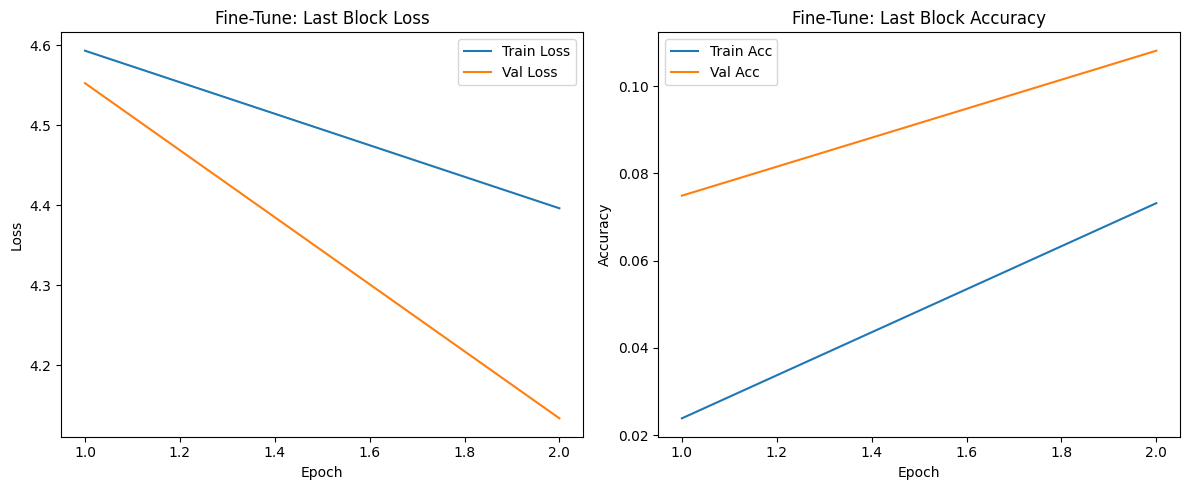

Exp1 Test Acc: 0.1196


In [11]:
plot_history(history_ft_1, "Fine-Tune: Last Block")

test_loss_ft_1, test_acc_ft_1 = evaluate(
    mobilenet_ft1,
    test_loader,
    criterion,
    device
)

print(f"Exp1 Test Acc: {test_acc_ft_1:.4f}")

In [12]:

# EXPERIMENT 2: UNFREEZE LAST TWO BLOCKS (11 + 12)

mobilenet_ft2 = models.mobilenet_v3_small(pretrained=True)

# Freeze everything
for param in mobilenet_ft2.parameters():
    param.requires_grad = False

# Replace classifier
in_features = mobilenet_ft2.classifier[3].in_features
mobilenet_ft2.classifier[3] = CustomClassifier(in_features)

# Unfreeze classifier
for param in mobilenet_ft2.classifier[3].parameters():
    param.requires_grad = True

# Unfreeze LAST TWO blocks
for param in mobilenet_ft2.features[12].parameters():
    param.requires_grad = True

for param in mobilenet_ft2.features[11].parameters():
    param.requires_grad = True

mobilenet_ft2 = mobilenet_ft2.to(device)

optimizer_ft_2 = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet_ft2.parameters()),
    lr=1e-4
)

print("Experiment 2 ready.")

Experiment 2 ready.


In [13]:
history_ft_2, ft_time_2 = train_model(
    mobilenet_ft2,
    train_loader,
    val_loader,
    criterion,
    optimizer_ft_2,
    device,
    num_epochs=2
)


Epoch 1/2


Train Loss: 4.5852 | Train Acc: 0.0278
Val Loss:   4.5261 | Val Acc:   0.0546
--------------------------------------------------

Epoch 2/2


Train Loss: 4.1965 | Train Acc: 0.0954
Val Loss:   3.7034 | Val Acc:   0.1741
--------------------------------------------------


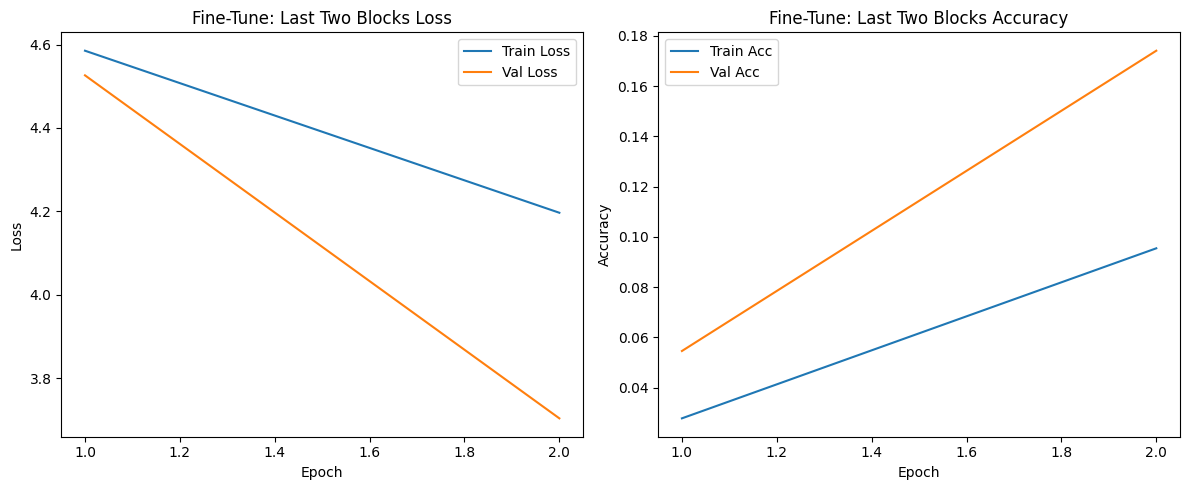

Exp2 Test Acc: 0.1873


In [14]:
plot_history(history_ft_2, "Fine-Tune: Last Two Blocks")

test_loss_ft_2, test_acc_ft_2 = evaluate(
    mobilenet_ft2,
    test_loader,
    criterion,
    device
)

print(f"Exp2 Test Acc: {test_acc_ft_2:.4f}")

In [15]:
# PART B BASELINE VALUES FROM PART A


baseline_test_acc = 0.3593
baseline_test_loss = 2.5918
baseline_training_time = 332.61

In [16]:
# PART B FINAL COMPARISON TABLE

finetune_results = pd.DataFrame({
    "Experiment": [
        "Baseline (Frozen Head Only)",
        "Unfreeze Last Block",
        "Unfreeze Last Two Blocks"
    ],
    "Test Accuracy": [
        baseline_test_acc,
        test_acc_ft_1,
        test_acc_ft_2
    ],
    "Test Loss": [
        baseline_test_loss,
        test_loss_ft_1,
        test_loss_ft_2
    ],
    "Training Time (s)": [
        baseline_training_time,
        ft_time_1,
        ft_time_2
    ],
    "Final Validation Accuracy": [
        0.3423,   # from Part A MobileNet
        history_ft_1["val_acc"][-1],
        history_ft_2["val_acc"][-1]
    ]
})

finetune_results.round(4)

,Experiment,Test Accuracy,Test Loss,Training Time (s),Final Validation Accuracy
0,Baseline (Frozen Head Only),0.3593,2.5918,332.6100,0.3423
1,Unfreeze Last Block,0.1196,4.0863,211.5999,0.1081
2,Unfreeze Last Two Blocks,0.1873,3.6122,288.4058,0.1741


### COMPARISON CHARTS

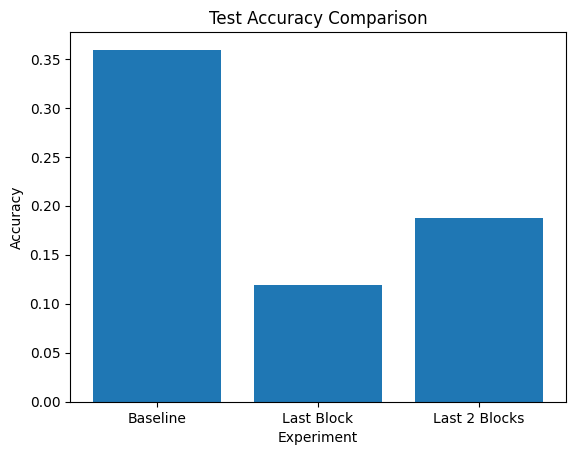

In [17]:

experiments = [
    "Baseline",
    "Last Block",
    "Last 2 Blocks"
]

test_accs = [
    0.3593,
    0.1196,
    0.1873
]

plt.figure()
plt.bar(experiments, test_accs)
plt.title("Test Accuracy Comparison")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.show()

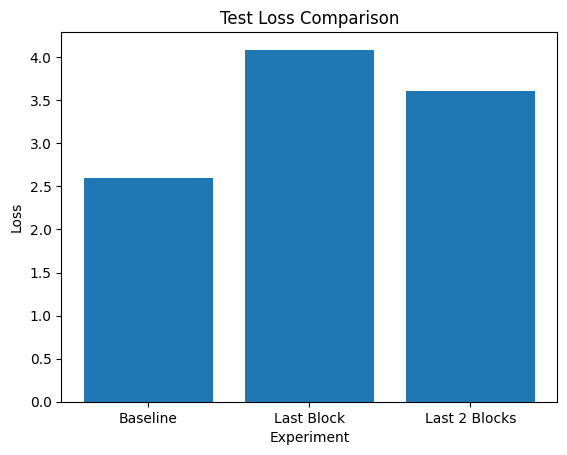

In [18]:
test_losses = [
    2.5918,
    4.0863,
    3.6122
]

plt.figure()
plt.bar(experiments, test_losses)
plt.title("Test Loss Comparison")
plt.xlabel("Experiment")
plt.ylabel("Loss")
plt.show()

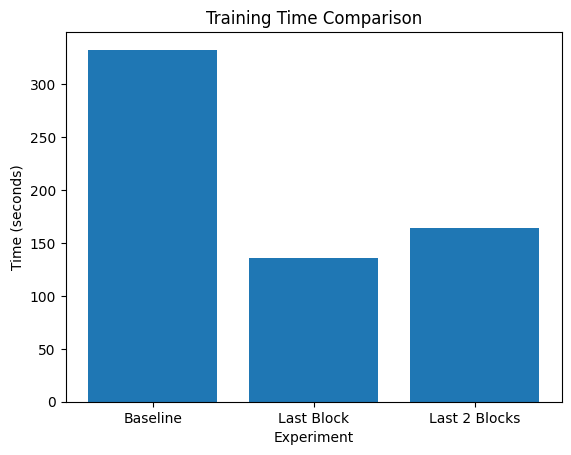

In [19]:
training_times = [
    332.61,
    136.26,
    164.56
]

plt.figure()
plt.bar(experiments, training_times)
plt.title("Training Time Comparison")
plt.xlabel("Experiment")
plt.ylabel("Time (seconds)")
plt.show()

### Fine-Tuning Comparison Summary

The baseline model with a frozen backbone achieved the highest test accuracy (0.3593), outperforming both fine-tuning approaches. 

Unfreezing the last block resulted in a significant drop in performance (0.1196), while unfreezing the last two blocks showed slight improvement (0.1873) but still underperformed compared to the baseline.

These results suggest that, for the given setup and limited training configuration, keeping the pre-trained backbone frozen provides better generalization. Fine-tuning deeper layers did not yield performance gains and introduced instability during training.